In [176]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from matplotlib.colors import LogNorm
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [177]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]
runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [179]:
files = ["build/200139.root:nt",
         "build/200140.root:nt",
         "build/200146.root:nt",]

data = uproot.concatenate(files, library="pd")

In [180]:
nu_vz = np.array([x[0] for x in data["truth_dec_z"].to_numpy()])

In [181]:
caloNu_tot_EM = data["CaloNu_total_E_EM"].to_numpy()

In [182]:
caloNu_tot_EM = np.nan_to_num(caloNu_tot_EM, nan=-1)
caloNu_tot_EM = np.where(caloNu_tot_EM > 1e7, 1e7, caloNu_tot_EM)
caloNu_tot_EM = caloNu_tot_EM / 1000  # convert to GeV

In [183]:
front = [-2987.39, -1945.67]
middle = [-2965.18, -2246.18]
back = [-2246.18, -1946.18]

In [184]:
# Get max energy for CaloNu for events in the front, middle, and back regions
front_caloNu = caloNu_tot_EM[(nu_vz > front[0]) & (nu_vz < front[1])]
middle_caloNu = caloNu_tot_EM[(nu_vz > middle[0]) & (nu_vz < middle[1])]
back_caloNu = caloNu_tot_EM[(nu_vz > back[0]) & (nu_vz < back[1])]

print(f"Front region: {front[0]} < z < {front[1]}, max CaloNu: {np.max(front_caloNu):.2f} GeV")
print(f"Middle region: {middle[0]} < z < {middle[1]}, max CaloNu: {np.max(middle_caloNu):.2f} GeV")
print(f"Back region: {back[0]} < z < {back[1]}, max CaloNu: {np.max(back_caloNu):.2f} GeV")

Front region: -2987.39 < z < -1945.67, max CaloNu: 1283.39 GeV
Middle region: -2965.18 < z < -2246.18, max CaloNu: 1283.39 GeV
Back region: -2246.18 < z < -1946.18, max CaloNu: 12.72 GeV


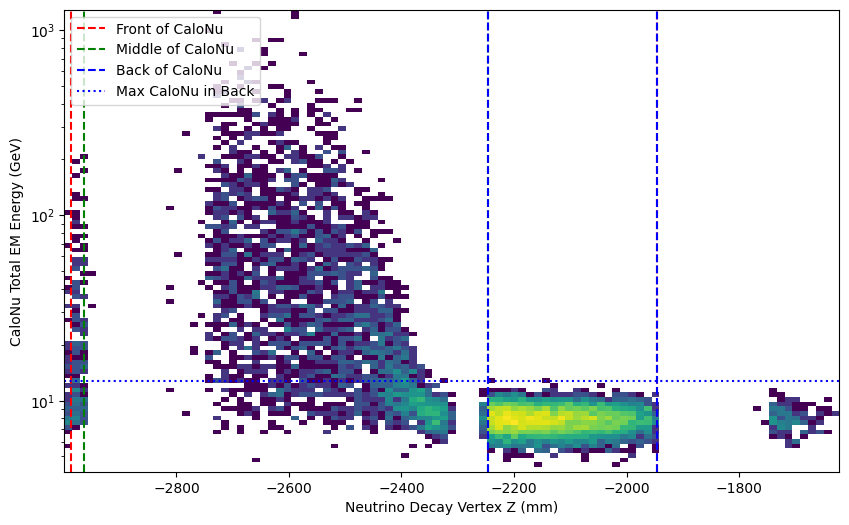

In [185]:
fig, ax = plt.subplots(figsize=(10, 6))

bins_x = np.linspace(np.min(nu_vz), np.max(nu_vz), 100)
bins_y = np.logspace(np.log10(np.min(caloNu_tot_EM[caloNu_tot_EM > 0])), np.log10(np.max(caloNu_tot_EM)), 100)

ax.hist2d(nu_vz, caloNu_tot_EM, bins=[bins_x, bins_y], cmap="viridis", norm=LogNorm())
ax.axvline(x=front[0], color='r', linestyle='--', label="Front of CaloNu")
ax.axvline(x=front[1], color='r', linestyle='--')
ax.axvline(x=middle[0], color='g', linestyle='--', label="Middle of CaloNu")
ax.axvline(x=middle[1], color='g', linestyle='--')
ax.axvline(x=back[0], color='b', linestyle='--', label="Back of CaloNu")
ax.axvline(x=back[1], color='b', linestyle='--')
# ax.axhline(y=np.max(front_caloNu), color='r', linestyle=':', label="Max CaloNu in Front")
# ax.axhline(y=np.max(middle_caloNu), color='g', linestyle=':', label="Max CaloNu in Middle")
ax.axhline(y=np.max(back_caloNu), color='b', linestyle=':', label="Max CaloNu in Back")
ax.set_xlabel("Neutrino Decay Vertex Z (mm)")
ax.set_ylabel("CaloNu Total EM Energy (GeV)")
ax.set_yscale("log")
ax.legend()


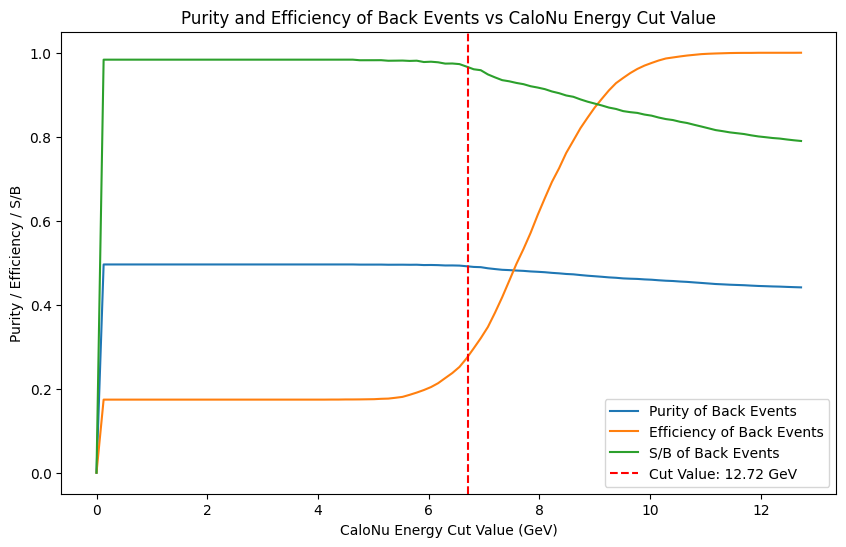

In [192]:
# Work out the efficiency of placing a cut on CaloNu energy to remove events in the back region

cut_value = np.max(back_caloNu)


purities = []
efficiencies = []
s_over_bs = []

for cut_value in np.linspace(0, np.max(back_caloNu), 100):
    # print(f"Cut value for CaloNu energy: {cut_value:.2f} GeV")

    front_caloNu = caloNu_tot_EM[(nu_vz > front[0]) & (nu_vz < front[1])]
    middle_caloNu = caloNu_tot_EM[(nu_vz > middle[0]) & (nu_vz < middle[1])]
    back_caloNu = caloNu_tot_EM[(nu_vz > back[0]) & (nu_vz < back[1])]

    number_of_true_front_events = len(front_caloNu)
    number_of_true_middle_events = len(middle_caloNu)
    number_of_true_back_events = len(back_caloNu)

    number_of_predicted_front_events = len(front_caloNu[front_caloNu < cut_value])
    number_of_predicted_middle_events = len(middle_caloNu[middle_caloNu < cut_value])
    number_of_predicted_back_events = len(back_caloNu[back_caloNu < cut_value])

    # print(f"Number of true front events: {number_of_true_front_events}")
    # print(f"Number of true middle events: {number_of_true_middle_events}")
    # print(f"Number of true back events: {number_of_true_back_events}")
    # print(f"Number of predicted front events: {number_of_predicted_front_events}")
    # print(f"Number of predicted middle events: {number_of_predicted_middle_events}")
    # print(f"Number of predicted back events: {number_of_predicted_back_events}")
    try:
        s_over_b = number_of_predicted_back_events / (number_of_predicted_front_events + number_of_predicted_middle_events)
        purity_back = number_of_predicted_back_events / (number_of_predicted_front_events + number_of_predicted_middle_events + number_of_predicted_back_events)
        efficiency_back = number_of_predicted_back_events / number_of_true_back_events
    except ZeroDivisionError:
        purity_back = 0
        efficiency_back = 0
        s_over_b = 0

    # print(f"Purity of back events: {purity_back:.2f}")
    # print(f"Efficiency of back events: {efficiency_back:.2f}")
    purities.append(purity_back)
    efficiencies.append(efficiency_back)
    s_over_bs.append(s_over_b)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.linspace(0, np.max(back_caloNu), 100), purities, label="Purity of Back Events")
ax.plot(np.linspace(0, np.max(back_caloNu), 100), efficiencies, label="Efficiency of Back Events")
ax.plot(np.linspace(0, np.max(back_caloNu), 100), s_over_bs, label="S/B of Back Events")

ax.axvline(x=6.7, color='r', linestyle='--', label=f"Cut Value: {cut_value:.2f} GeV")

ax.set_xlabel("CaloNu Energy Cut Value (GeV)")
ax.set_ylabel("Purity / Efficiency / S/B")
ax.set_title("Purity and Efficiency of Back Events vs CaloNu Energy Cut Value")
ax.legend()

Text(0, 0.5, 'Number of Events')

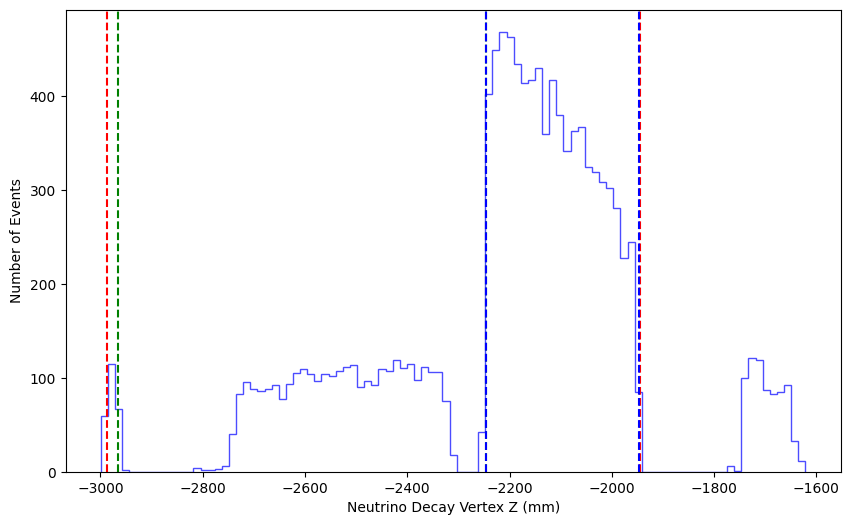

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
bins_x = np.linspace(np.min(nu_vz), np.max(nu_vz), 100)

ax.hist(nu_vz, bins=bins_x, color='blue', alpha=0.7, histtype='step', label="Neutrino Decay Vertex Z Distribution")
ax.axvline(x=front[0], color='r', linestyle='--', label="Front of CaloNu")
ax.axvline(x=front[1], color='r', linestyle='--')
ax.axvline(x=middle[0], color='g', linestyle='--', label="Middle of CaloNu")
ax.axvline(x=middle[1], color='g', linestyle='--')
ax.axvline(x=back[0], color='b', linestyle='--', label="Back of CaloNu")
ax.axvline(x=back[1], color='b', linestyle='--')
ax.set_xlabel("Neutrino Decay Vertex Z (mm)")
ax.set_ylabel("Number of Events")  

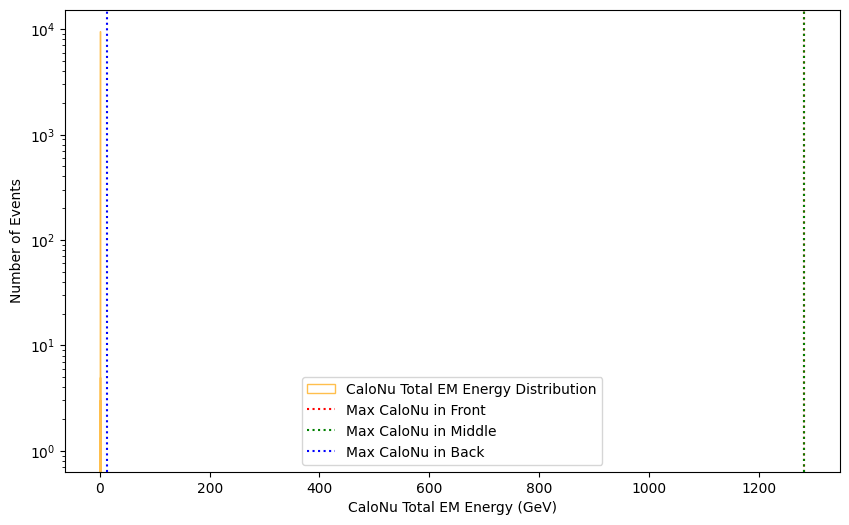

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
bins_x = np.linspace(np.min(caloNu_tot_EM), np.max(caloNu_tot_EM), 100)
ax.hist(caloNu_tot_EM, bins=bins_x, color='orange', alpha=0.7, histtype='step', label="CaloNu Total EM Energy Distribution")
ax.axvline(x=np.max(front_caloNu), color='r', linestyle=':', label="Max CaloNu in Front")
ax.axvline(x=np.max(middle_caloNu), color='g', linestyle=':', label="Max CaloNu in Middle")
ax.axvline(x=np.max(back_caloNu), color='b', linestyle=':', label="Max CaloNu in Back")
ax.set_xlabel("CaloNu Total EM Energy (GeV)")
ax.set_ylabel("Number of Events")
ax.set_yscale("log")
ax.legend()

In [ ]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")
calonu_data_files = []
for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])
    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}:nt")

In [ ]:
print(f"Found {len(calonu_data_files)} CaloNu data files in the range {runs_caloNu[0]} to {runs_caloNu[1]}.")

Found 130 CaloNu data files in the range 15821 to 16924.


In [209]:
df_data = uproot.concatenate(calonu_data_files, library="pd")

mc_files = ["build/200139.root:nt",
         "build/200140.root:nt",
         "build/200146.root:nt",]

df_mc = uproot.concatenate(mc_files, library="pd")

n_events_data = len(df_data)
n_events_mc = len(df_mc) * (70.03 / 10_000)

print(f"Number of events in data {n_events_data}")
print(f"Number of events in MC {n_events_mc:.2f}")
print(f"Ratio of data to MC = {n_events_data / n_events_mc:.2f}")

Number of events in data 229
Number of events in MC 83.34
Ratio of data to MC = 2.75


In [210]:
status_cols = ["CaloNu0_status", "CaloNu1_status", "CaloNu2_status", "CaloNu3_status"]

df_data["Saturated_CaloNu_Module"] = (df_data[status_cols] == 4).any(axis=1).copy()
df_mc["Saturated_CaloNu_Module"] = (df_mc[status_cols] == 4).any(axis=1).copy()

/tmp/ipykernel_2129686/3728578096.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_data["Saturated_CaloNu_Module"] = (df_data[status_cols] == 4).any(axis=1).copy()
/tmp/ipykernel_2129686/3728578096.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc["Saturated_CaloNu_Module"] = (df_mc[status_cols] == 4).any(axis=1).copy()


In [211]:
caloNu_tot_EM_data = df_data["CaloNu_total_E_EM"].to_numpy()
caloNu_tot_EM_data = np.nan_to_num(caloNu_tot_EM_data, nan=-1)
caloNu_tot_EM_data = np.where(caloNu_tot_EM_data > 1e7, 1e7, caloNu_tot_EM_data)
caloNu_tot_EM_data = caloNu_tot_EM_data / 1000  # convert to GeV

caloNu_tot_EM_mc = df_mc["CaloNu_total_E_EM"].to_numpy()
caloNu_tot_EM_mc = np.nan_to_num(caloNu_tot_EM_mc, nan=-1)
caloNu_tot_EM_mc = np.where(caloNu_tot_EM_mc > 1e7, 1e7, caloNu_tot_EM_mc)
caloNu_tot_EM_mc = caloNu_tot_EM_mc / 1000  # convert to GeV

In [212]:
df_data["Average_CaloNu_localtime"] = df_data[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].mean(axis=1).copy()
df_mc["Average_CaloNu_localtime"] = df_mc[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].mean(axis=1).copy()

df_data["Min_CaloNu_localtime"] = df_data[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].min(axis=1).copy()
df_mc["Min_CaloNu_localtime"] = df_mc[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].min(axis=1).copy()

df_data["Max_CaloNu_localtime"] = df_data[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].max(axis=1).copy()
df_mc["Max_CaloNu_localtime"] = df_mc[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].max(axis=1).copy()

df_data["Average_CaloNu_bcidtime"] = df_data[["CaloNu0_bcidtime", "CaloNu1_bcidtime", "CaloNu2_bcidtime", "CaloNu3_bcidtime"]].mean(axis=1).copy()
df_mc["Average_CaloNu_bcidtime"] = df_mc[["CaloNu0_bcidtime", "CaloNu1_bcidtime", "CaloNu2_bcidtime", "CaloNu3_bcidtime"]].mean(axis=1).copy()

df_data["Average_CaloNu_triggertime"] = df_data[["CaloNu0_triggertime", "CaloNu1_triggertime", "CaloNu2_triggertime", "CaloNu3_triggertime"]].mean(axis=1).copy()
df_mc["Average_CaloNu_triggertime"] = df_mc[["CaloNu0_triggertime", "CaloNu1_triggertime", "CaloNu2_triggertime", "CaloNu3_triggertime"]].mean(axis=1).copy()

/tmp/ipykernel_2129686/3508738376.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_data["Average_CaloNu_localtime"] = df_data[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].mean(axis=1).copy()
/tmp/ipykernel_2129686/3508738376.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_mc["Average_CaloNu_localtime"] = df_mc[["CaloNu0_localtime", "CaloNu1_localtime", "CaloNu2_localtime", "CaloNu3_localtime"]].mean(axis=1).copy()
/tmp/ipykernel_2129686/3508738376.py:4: PerformanceWarning: Da

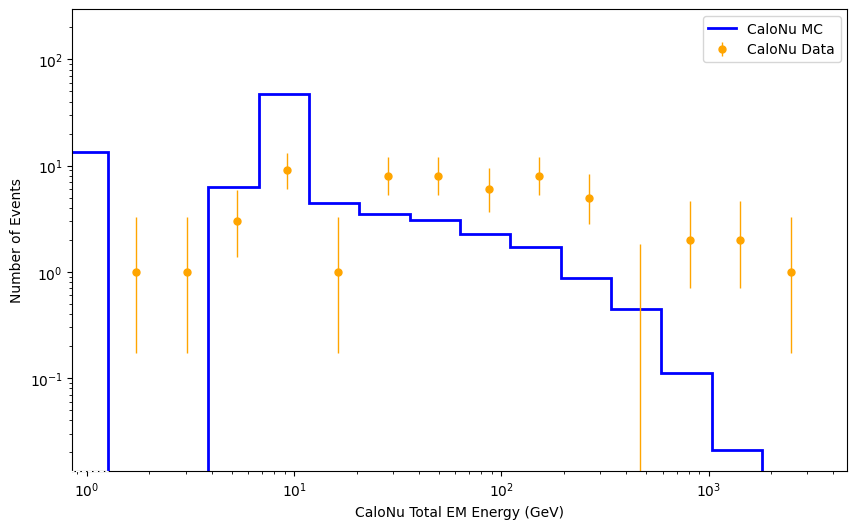

In [213]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.logspace(0.1, 3.5, 15)


h_mc = bh.Histogram(bh.axis.Variable(bins))
h_mc.fill(caloNu_tot_EM_mc, weight=70.03 / 10_000 ) # Normalise to lumi

h_data = bh.Histogram(bh.axis.Variable(bins))
h_data.fill(caloNu_tot_EM_data)  # convert to GeV

mplhep.histplot(h_data, ax=ax, label="CaloNu Data", color='orange', histtype='errorbar', linewidth=2, flow='show')
mplhep.histplot(h_mc, ax=ax, label="CaloNu MC", color='blue', histtype='step', linewidth=2, flow='show')

ax.set_xlabel("CaloNu Total EM Energy (GeV)")
ax.set_ylabel("Number of Events")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()

Text(0, 0.5, 'Average CaloNu Local Time (ns)')

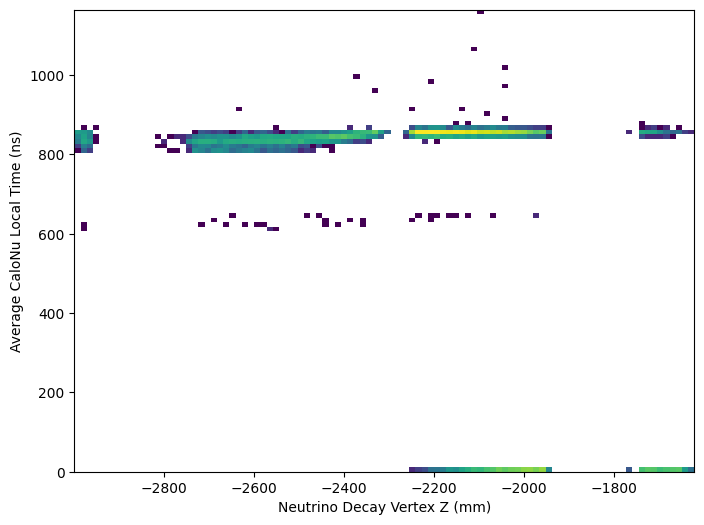

In [214]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
vz_mc = np.array([x[0] for x in df_mc["truth_dec_z"].to_numpy()])
ax.hist2d(vz_mc, df_mc["Average_CaloNu_localtime"].to_numpy(), bins=[100, 100], cmap="viridis", norm=LogNorm());
ax.set_xlabel("Neutrino Decay Vertex Z (mm)")
ax.set_ylabel("Average CaloNu Local Time (ns)")

Text(0, 0.5, 'Minimum CaloNu Local Time (ns)')

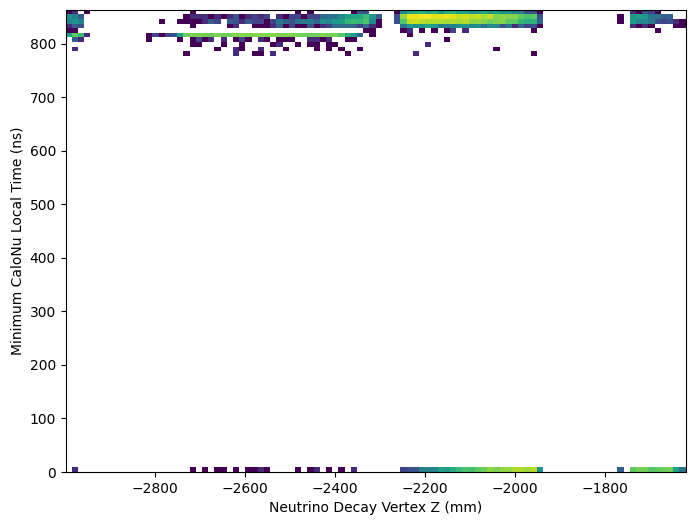

In [215]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
vz_mc = np.array([x[0] for x in df_mc["truth_dec_z"].to_numpy()])
ax.hist2d(vz_mc, df_mc["Min_CaloNu_localtime"].to_numpy(), bins=[100, 100], cmap="viridis", norm=LogNorm());
ax.set_xlabel("Neutrino Decay Vertex Z (mm)")
ax.set_ylabel("Minimum CaloNu Local Time (ns)")

Text(0, 0.5, 'Maximum CaloNu Local Time (ns)')

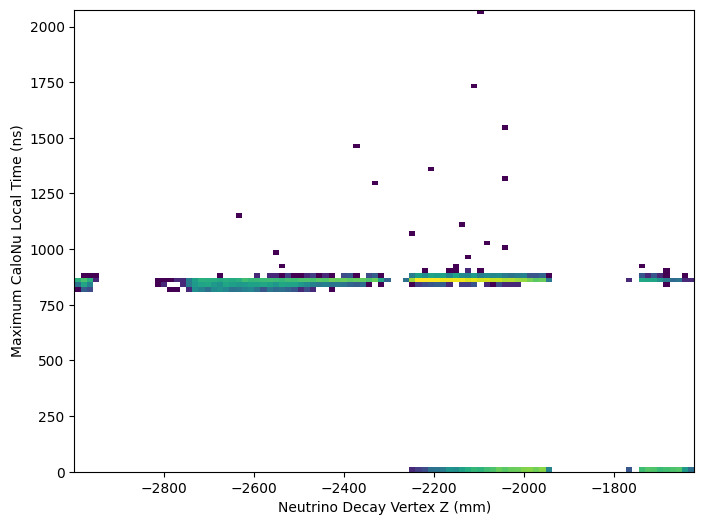

In [216]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
vz_mc = np.array([x[0] for x in df_mc["truth_dec_z"].to_numpy()])
ax.hist2d(vz_mc, df_mc["Max_CaloNu_localtime"].to_numpy(), bins=[100, 100], cmap="viridis", norm=LogNorm());
ax.set_xlabel("Neutrino Decay Vertex Z (mm)")
ax.set_ylabel("Maximum CaloNu Local Time (ns)")

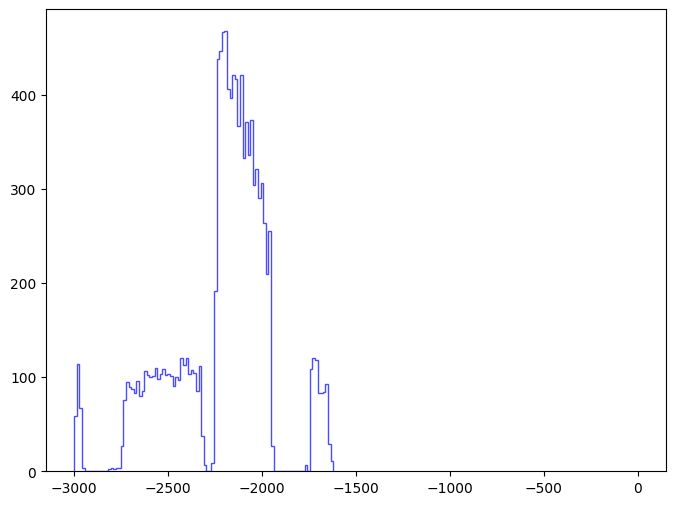

In [217]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

df_mc_saturated = df_mc[df_mc["Saturated_CaloNu_Module"] == True]
df_mc_not_saturated = df_mc[df_mc["Saturated_CaloNu_Module"] == False]

vz_mc_saturated = np.array([x[0] for x in df_mc_saturated["truth_dec_z"].to_numpy()])
vz_mc_not_saturated = np.array([x[0] for x in df_mc_not_saturated["truth_dec_z"].to_numpy()])

ax.hist(vz_mc_saturated, bins=100, color='red', alpha=0.7, histtype='step', label="Saturated CaloNu Events");
ax.hist(vz_mc_not_saturated, bins=100, color='blue', alpha=0.7, histtype='step', label="Not Saturated CaloNu Events");

{np.int32(32), np.int32(1), np.int32(0), np.int32(16), np.int32(48)}


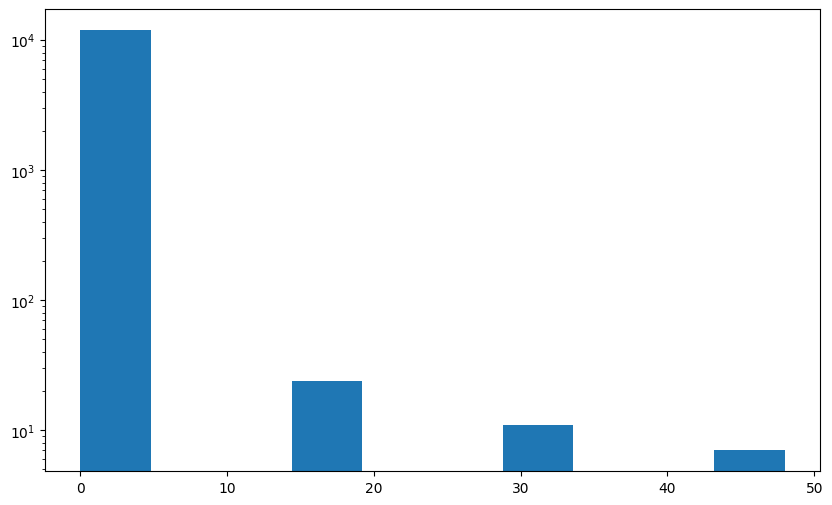

In [218]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_mc["CaloNu0_status"])
ax.set_yscale("log")
print(set(df_mc["CaloNu0_status"].to_numpy()))

{np.int32(0), np.int32(16)}


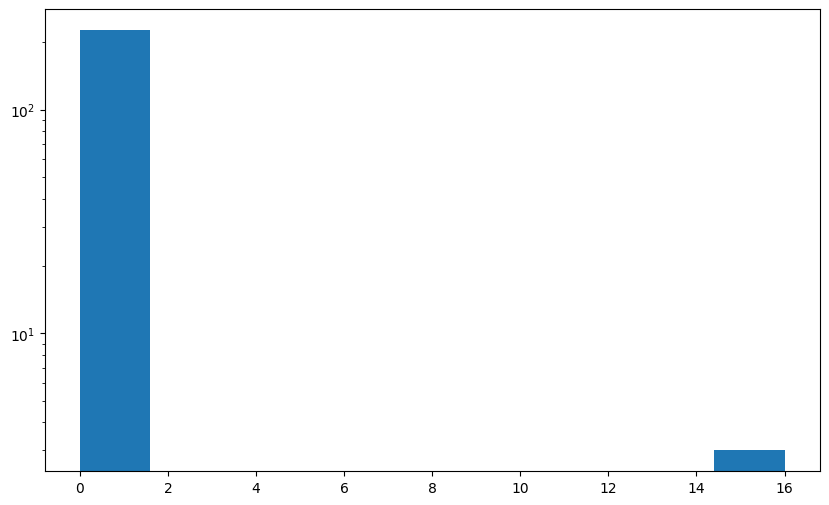

In [219]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_data["Preshower0_status"])
ax.set_yscale("log")
print(set(df_data["Preshower0_status"].to_numpy()))

{np.int32(0), np.int32(16)}


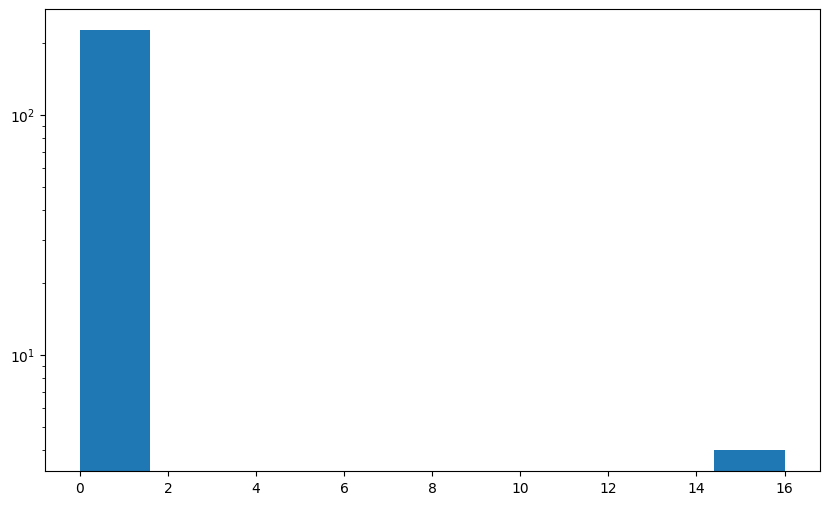

In [220]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_data["Preshower1_status"])
ax.set_yscale("log")
print(set(df_data["Preshower1_status"].to_numpy()))

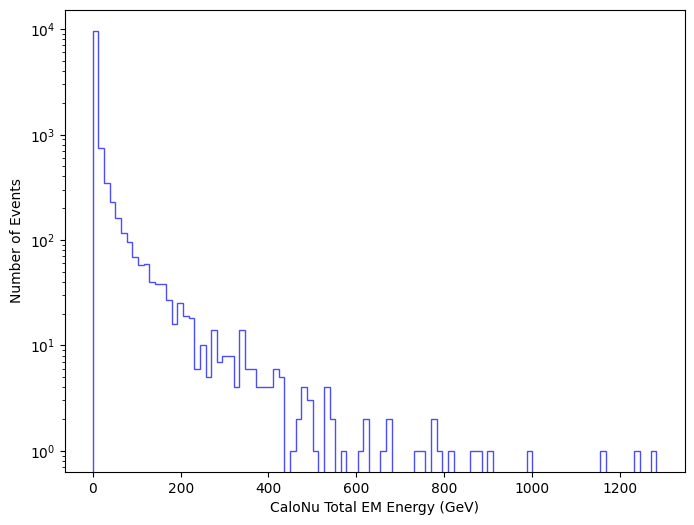

In [221]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.hist(caloNu_tot_EM_mc, bins=100, color='blue', alpha=0.7, histtype='step', label="CaloNu MC Total EM Energy Distribution")
ax.set_xlabel("CaloNu Total EM Energy (GeV)")
ax.set_ylabel("Number of Events")
ax.set_yscale("log")

In [222]:
cut_val = 6.7

df_data_below = df_data[df_data["CaloNu_total_E_EM"] < cut_val * 1000]
df_data_above = df_data[df_data["CaloNu_total_E_EM"] >= cut_val * 1000]

df_mc_below = df_mc[df_mc["CaloNu_total_E_EM"] < cut_val * 1000]
df_mc_above = df_mc[df_mc["CaloNu_total_E_EM"] >= cut_val * 1000]

bins = np.linspace(-1, 30, 31)

h_data_reduced_charge0_below = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0_below.fill(df_data_below["VetoNu0_reduced_charge"].to_numpy())

h_data_reduced_charge0_above = bh.Histogram(bh.axis.Variable(bins))
h_data_reduced_charge0_above.fill(df_data_above["VetoNu0_reduced_charge"].to_numpy())

h_mc_reduced_charge0_above = bh.Histogram(bh.axis.Variable(bins))
h_mc_reduced_charge0_above.fill(df_mc_above["VetoNu0_reduced_charge"].to_numpy(), weight=70.03 / 10_000 ) # Normalise to lumi

h_mc_reduced_charge0_below = bh.Histogram(bh.axis.Variable(bins))
h_mc_reduced_charge0_below.fill(df_mc_below["VetoNu0_reduced_charge"].to_numpy(), weight=70.03 / 10_000 ) # Normalise to lumi


print(f"Number of events in data below cut: {len(df_data_below)}, number of events in MC below cut: {len(df_mc_below)*70.03 / 10_000:.2f}")
print(f"Number of events in data above cut: {len(df_data_above)}, number of events in MC above cut: {len(df_mc_above)*70.03 / 10_000:.2f}")


Number of events in data below cut: 179, number of events in MC below cut: 19.27
Number of events in data above cut: 50, number of events in MC above cut: 64.00


In [223]:
n_events_data = len(df_data)
n_events_mc = len(df_mc) * 70.03 / 10_000

print(f"Number of events in data {n_events_data}")
print(f"Number of events in MC {n_events_mc:.2f}")
print(f"Ratio of data to MC = {n_events_data / n_events_mc:.2f}")

Number of events in data 229
Number of events in MC 83.34
Ratio of data to MC = 2.75


/tmp/ipykernel_2129686/2244372972.py:10: RuntimeWarning: divide by zero encountered in divide
  ratio_hist = h_data_reduced_charge0_below.view() / h_mc_reduced_charge0_below.view()
/tmp/ipykernel_2129686/2244372972.py:10: RuntimeWarning: invalid value encountered in divide
  ratio_hist = h_data_reduced_charge0_below.view() / h_mc_reduced_charge0_below.view()
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:649: RuntimeWarning: invalid value encountered in subtract
  return values - np.sqrt(variances), values + np.sqrt(variances)
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: invalid value encountered in subtract
  return np.abs(method_fcn(self.values(), variances) - self.values())


Text(0, 0.5, 'Data / MC')

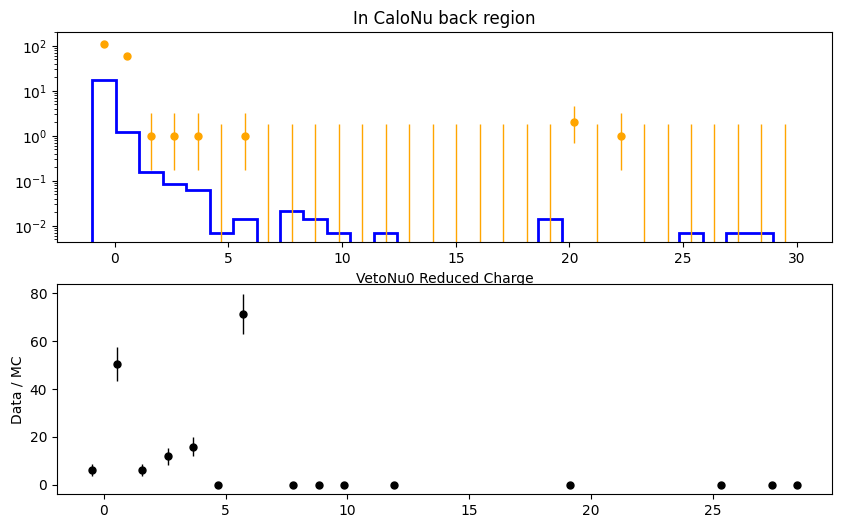

In [224]:



fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))
mplhep.histplot(h_data_reduced_charge0_below, ax=ax[0], label="CaloNu Data Below Cut", color='orange', histtype='errorbar', linewidth=2, flow='show')
mplhep.histplot(h_mc_reduced_charge0_below, ax=ax[0], label="CaloNu MC Below Cut", color='blue', histtype='step', linewidth=2, flow='show')
ax[0].set_yscale("log")
ax[0].set_xlabel("VetoNu0 Reduced Charge")
ax[0].set_title("In CaloNu back region")
# Ratio plot
ratio = h_data_reduced_charge0_below / h_mc_reduced_charge0_below

ratio_hist = h_data_reduced_charge0_below.view() / h_mc_reduced_charge0_below.view()
ratio_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
ratio_hist.view()[:] = ratio


mplhep.histplot(ratio_hist, ax=ax[1], histtype="errorbar", color="black")
ax[1].set_ylabel("Data / MC")

/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:649: RuntimeWarning: invalid value encountered in subtract
  return values - np.sqrt(variances), values + np.sqrt(variances)
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: invalid value encountered in subtract
  return np.abs(method_fcn(self.values(), variances) - self.values())


Text(0, 0.5, 'Data / MC')

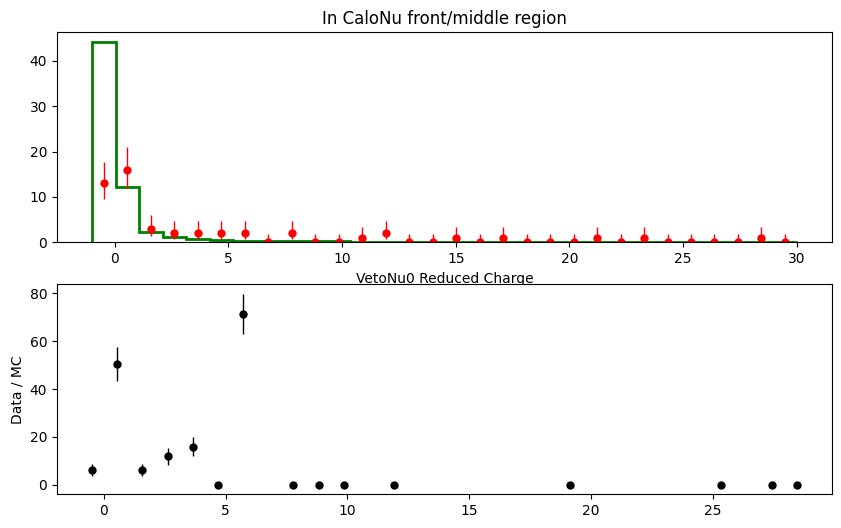

In [225]:
fig, ax = plt.subplots(figsize=(10, 6), nrows=2)
mplhep.histplot(h_data_reduced_charge0_above, ax=ax[0], label="CaloNu Data Above Cut", color='red', histtype='errorbar', linewidth=2, flow='show')
mplhep.histplot(h_mc_reduced_charge0_above, ax=ax[0], label="CaloNu MC Above Cut", color='green', histtype='step', linewidth=2, flow='show')
ax[0].set_xlabel("VetoNu0 Reduced Charge")
ax[0].set_title("In CaloNu front/middle region")

ratio_hist = h_data_reduced_charge0_above.view() / h_mc_reduced_charge0_above.view()
ratio_hist = bh.Histogram(bh.axis.Regular(bins.size - 1, bins[0], bins[-1]))
ratio_hist.view()[:] = ratio

mplhep.histplot(ratio_hist, ax=ax[1], histtype="errorbar", color="black")
ax[1].set_ylabel("Data / MC")

